# PROJECT TITLE : AI System to detect Drop-out Risk of Girls in Education

## Project Motivation : Girls drop out of school due to socio-economic, academic and environmental challenges. This project aims to build a machine learning model that predicts drop-out risk early so that the intervention can be planned.


### Importing the libraries

In [514]:
import pandas as pd

In [515]:
import numpy as np

In [516]:
import matplotlib.pyplot as plt

In [517]:
import seaborn as sns

In [518]:
from sklearn.model_selection import train_test_split

In [519]:
from sklearn.preprocessing import StandardScaler

In [520]:
from sklearn.linear_model import LogisticRegression

In [521]:
from sklearn.ensemble import RandomForestClassifier

In [522]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [523]:
from sklearn.metrics import roc_curve, auc

In [524]:
from sklearn.model_selection import cross_val_score

In [525]:
from sklearn.model_selection import GridSearchCV

In [526]:
import joblib


In [527]:
joblib.dump(model, "dropout_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### Creating a synthetic dataset

In [528]:
np.random.seed(42)

In [529]:
n = 500

In [530]:
# Basic details
age = np.random.randint(11, 18, n)
attendance = np.random.randint(50, 100, n)

# Socio-economic factors
household_income = np.random.randint(60000, 300000, n)  # yearly income in INR
parents_education_level = np.random.randint(0, 5, n)  
# 0 = no schooling, 4 = graduate

# Location & access
rural_area = np.random.randint(0, 2, n) 
distance_to_school_km = np.random.randint(1, 15, n)

# Infrastructure & support
has_toilet_at_school = np.random.randint(0, 2, n)
receives_scholarship = np.random.randint(0, 2, n)
has_menstrual_hygiene_access = np.random.randint(0, 2, n)

# Work burden
helps_in_household_work = np.random.randint(0, 2, n)
works_after_school = np.random.randint(0, 2, n)

# Early marriage risk
early_marriage_risk = np.random.randint(0, 2, n)

In [531]:
# Logical dropout rule (Indian context)
risk_score = (
    (attendance < 65).astype(int) +
    (household_income < 100000).astype(int) +
    (distance_to_school_km > 10).astype(int) +
    (parents_education_level <= 1).astype(int) +
    (rural_area == 1).astype(int) +
    (has_toilet_at_school == 0).astype(int) +
    (has_menstrual_hygiene_access == 0).astype(int) +
    (helps_in_household_work == 1).astype(int) +
    (works_after_school == 1).astype(int) +
    (early_marriage_risk == 1).astype(int)
)

dropout_risk = (risk_score >= 5).astype(int)

In [532]:
df = pd.DataFrame({
    "age": age,
    "attendance": attendance,
    "household_income": household_income,
    "parents_education_level": parents_education_level,
    "rural_area": rural_area,
    "distance_to_school_km": distance_to_school_km,
    "has_toilet_at_school": has_toilet_at_school,
    "receives_scholarship": receives_scholarship,
    "has_menstrual_hygiene_access": has_menstrual_hygiene_access,
    "helps_in_household_work": helps_in_household_work,
    "works_after_school": works_after_school,
    "early_marriage_risk" : early_marriage_risk,
    "dropout_risk": dropout_risk
})

In [533]:
df.head()

,age,attendance,household_income,parents_education_level,rural_area,distance_to_school_km,has_toilet_at_school,receives_scholarship,has_menstrual_hygiene_access,helps_in_household_work,works_after_school,early_marriage_risk,dropout_risk
0,17,64,110428,1,1,2,1,1,0,1,0,0,1
1,14,92,278803,1,1,1,1,0,0,1,1,0,1
2,15,86,191374,0,1,13,1,1,0,1,0,1,1
3,17,82,273630,4,1,4,1,1,0,1,0,1,0
4,13,57,191127,2,0,10,1,1,0,1,0,1,0


### Data Cleaning

In [534]:
df["dropout_risk"].value_counts()

dropout_risk
0    307
1    193
Name: count, dtype: int64

In [535]:
df.info

<bound method DataFrame.info of      age  attendance  household_income  parents_education_level  rural_area  \
0     17          64            110428                        1           1   
1     14          92            278803                        1           1   
2     15          86            191374                        0           1   
3     17          82            273630                        4           1   
4     13          57            191127                        2           0   
..   ...         ...               ...                      ...         ...   
495   16          85            297732                        0           1   
496   11          50            187157                        3           1   
497   14          57            181300                        3           1   
498   12          98            146925                        0           1   
499   16          84            126358                        1           1   

     distance_to_sc

In [536]:
df.describe

<bound method NDFrame.describe of      age  attendance  household_income  parents_education_level  rural_area  \
0     17          64            110428                        1           1   
1     14          92            278803                        1           1   
2     15          86            191374                        0           1   
3     17          82            273630                        4           1   
4     13          57            191127                        2           0   
..   ...         ...               ...                      ...         ...   
495   16          85            297732                        0           1   
496   11          50            187157                        3           1   
497   14          57            181300                        3           1   
498   12          98            146925                        0           1   
499   16          84            126358                        1           1   

     distance_to_

### Data Visualization

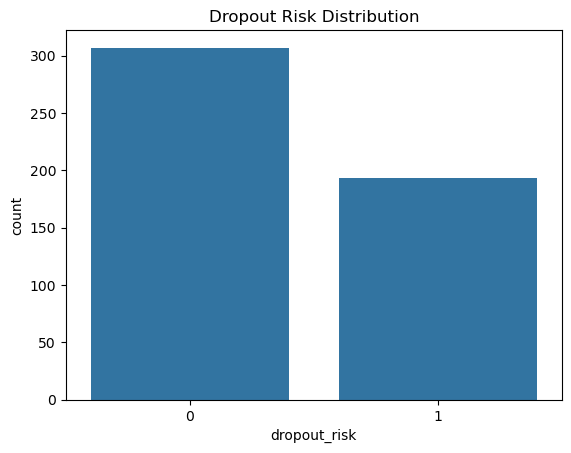

In [537]:
sns.countplot(x = "dropout_risk", data = df)
plt.title("Dropout Risk Distribution")
plt.show()

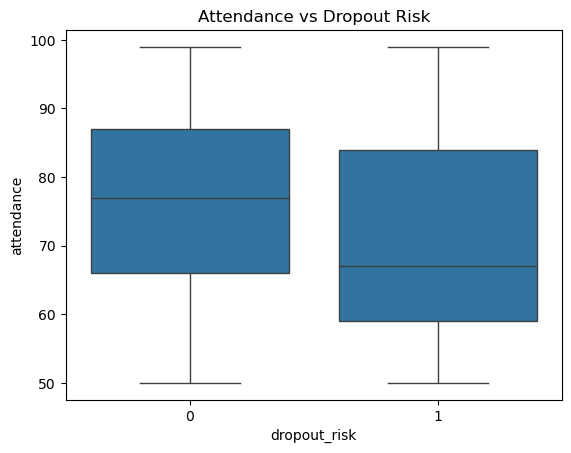

In [538]:
sns.boxplot(x = "dropout_risk", y = "attendance", data = df)
plt.title("Attendance vs Dropout Risk")
plt.show()

In [539]:
X = df.drop("dropout_risk", axis = 1)
y = df["dropout_risk"]

In [540]:
X.head()

,age,attendance,household_income,parents_education_level,rural_area,distance_to_school_km,has_toilet_at_school,receives_scholarship,has_menstrual_hygiene_access,helps_in_household_work,works_after_school,early_marriage_risk
0,17,64,110428,1,1,2,1,1,0,1,0,0
1,14,92,278803,1,1,1,1,0,0,1,1,0
2,15,86,191374,0,1,13,1,1,0,1,0,1
3,17,82,273630,4,1,4,1,1,0,1,0,1
4,13,57,191127,2,0,10,1,1,0,1,0,1


### Train-test Split

In [541]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [542]:
print("Training size : ",X_train.shape)

Training size :  (400, 12)


In [543]:
print("Testing size : ",X_test.shape)

Testing size :  (100, 12)


### Feature Scaling

In [544]:
scaler = StandardScaler()

In [545]:
X_train_scaled = scaler.fit_transform(X_train)

In [546]:
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [547]:
model = LogisticRegression(max_iter = 2000)

In [548]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [549]:
y_pred = model.predict(X_test_scaled)

In [550]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [551]:
y_prob[:10]

array([9.84708561e-01, 2.41676669e-01, 7.44666165e-02, 5.43416972e-04,
       3.70433586e-01, 5.96247761e-01, 1.39105762e-01, 9.39751502e-01,
       4.09358119e-02, 9.99185966e-01])

In [552]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85


In [553]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        61
           1       0.88      0.72      0.79        39

    accuracy                           0.85       100
   macro avg       0.86      0.83      0.84       100
weighted avg       0.85      0.85      0.85       100



In [554]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[57  4]
 [11 28]]


### Creating Risk Categories

In [555]:
def categorize_risk(prob):
    if prob < 0.4 :
        return "Low"
    elif prob < 0.7 :
        return "Medium"
    else:
        return "High"

In [556]:
risk_category = [categorize_risk(p) for p in y_prob]

In [557]:
risk_category[:10]

['High', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'High', 'Low', 'High']

In [558]:
results_df = X_test.copy()

results_df["Actual"] = y_test.values
results_df["Predicted"] = y_pred
results_df["Risk_Probability"] = y_prob
results_df["Risk_Category"] = risk_category

results_df.head()

,age,attendance,household_income,parents_education_level,rural_area,distance_to_school_km,has_toilet_at_school,receives_scholarship,has_menstrual_hygiene_access,helps_in_household_work,works_after_school,early_marriage_risk,Actual,Predicted,Risk_Probability,Risk_Category
361,12,54,117545,1,1,7,0,1,0,0,1,0,1,1,0.984709,High
73,15,72,135703,4,1,12,1,0,1,1,0,1,0,0,0.241677,Low
374,17,63,68070,1,0,5,1,1,0,0,1,0,1,0,0.074467,Low
155,13,86,225459,2,1,12,1,0,1,0,0,0,0,0,0.000543,Low
104,16,52,101427,2,0,1,0,1,0,0,0,1,0,0,0.370434,Low


### Random Forest Classification

In [559]:
rf = RandomForestClassifier(n_estimators = 200, random_state = 42)

In [560]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [561]:
y_pred_rf = rf.predict(X_test)

In [562]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.81


In [563]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        61
           1       0.88      0.59      0.71        39

    accuracy                           0.81       100
   macro avg       0.83      0.77      0.78       100
weighted avg       0.82      0.81      0.80       100



In [564]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:
[[58  3]
 [16 23]]


In [565]:
df["dropout_risk"].value_counts()

dropout_risk
0    307
1    193
Name: count, dtype: int64

### Logistic Regression vs Random Forest

In [566]:
logistic_accuracy = accuracy_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy: ", logistic_accuracy)
print("Random Forest Accuracy: ", rf_accuracy)

Logistic Regression Accuracy:  0.85
Random Forest Accuracy:  0.81


### Feature Importance

In [567]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,attendance,0.153237
2,household_income,0.146002
5,distance_to_school_km,0.133300
3,parents_education_level,0.097094
6,has_toilet_at_school,0.077857
10,works_after_school,0.074457
0,age,0.063651
11,early_marriage_risk,0.062094
9,helps_in_household_work,0.058076
8,has_menstrual_hygiene_access,0.055459


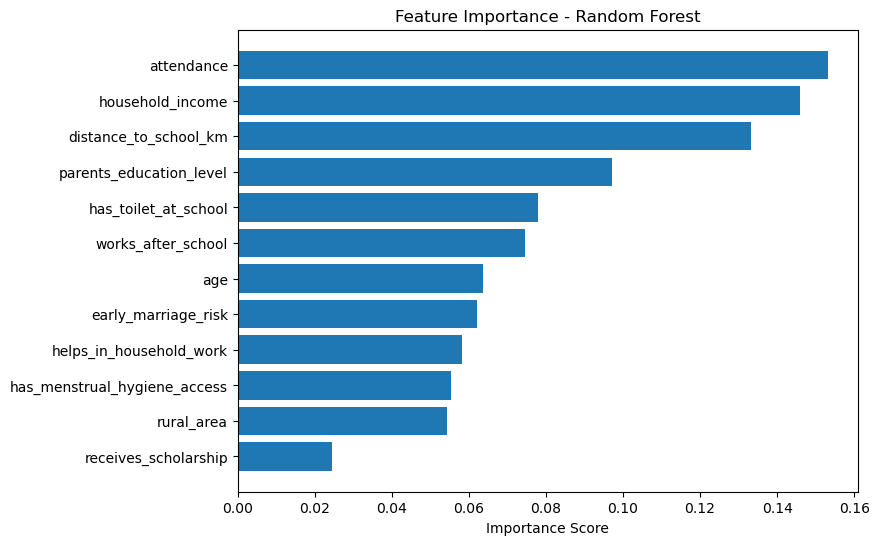

In [568]:
plt.figure(figsize = (8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

### Creation of ROC Curve with the help of AUC Score

In [569]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

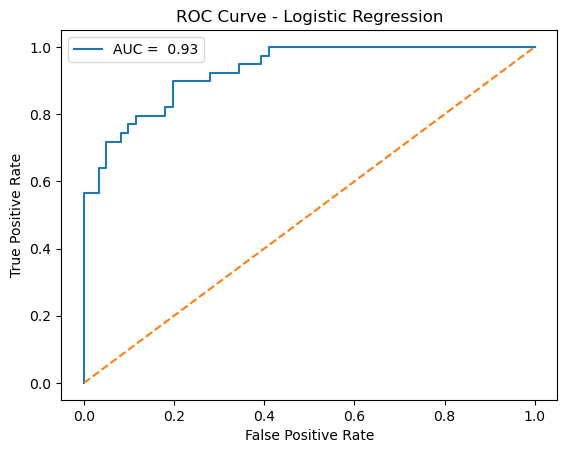

In [570]:
plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc : .2f}")
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [571]:
print("AUC Score: ", roc_auc)

AUC Score:  0.9298024379991593


### Cross-Validation for Logistic Regression

In [572]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv = 5)

In [573]:
print("Cross Validation Scores: ", cv_scores)
print("Average CV Score: ", cv_scores.mean())

Cross Validation Scores:  [0.9125 0.9    0.825  0.85   0.9375]
Average CV Score:  0.8850000000000001


### Cross-Validation for Random Forest Classification

In [574]:
cv_rf = cross_val_score(rf, X_train, y_train, cv = 5)

In [575]:
print("Random Forest CV Score: ", cv_rf)
print("Average RF Score: ", cv_rf.mean())

Random Forest CV Score:  [0.9    0.8375 0.825  0.9    0.875 ]
Average RF Score:  0.8675


### Early Warning System Table

In [576]:
high_risk_students = results_df.sort_values(
    by="Risk_Probability",
    ascending=False
)

high_risk_students.head(15)

,age,attendance,household_income,parents_education_level,rural_area,distance_to_school_km,has_toilet_at_school,receives_scholarship,has_menstrual_hygiene_access,helps_in_household_work,works_after_school,early_marriage_risk,Actual,Predicted,Risk_Probability,Risk_Category
455,13,53,135629,4,1,6,0,0,0,1,1,1,1,1,0.999446,High
72,14,86,186394,0,1,3,0,1,0,1,1,1,1,1,0.999359,High
450,12,60,108770,2,1,11,0,1,0,1,1,0,1,1,0.999186,High
84,16,94,61605,0,1,11,0,1,0,1,1,0,1,1,0.998936,High
262,16,77,119201,0,0,14,0,0,1,1,1,1,1,1,0.997951,High
497,14,57,181300,3,1,10,0,0,0,1,0,1,1,1,0.997684,High
76,16,85,172581,0,1,7,1,0,0,1,1,1,1,1,0.996536,High
101,17,92,229182,1,1,13,0,1,0,1,1,0,1,1,0.995911,High
485,16,58,94911,4,1,8,0,1,0,0,1,1,1,1,0.994277,High
336,13,54,194869,4,1,9,0,0,1,1,1,1,1,1,0.992558,High


### Hyper-Parameter Tuning

In [577]:
param_grid = {
    "C" : [0.01, 0.1, 1, 10, 100],
    "solver" : ["lbfgs", "liblinear"],
    "penalty" : ["l2"]
}

In [578]:
grid = GridSearchCV(
    LogisticRegression(max_iter = 2000),
    param_grid,
    cv = 5,
    scoring = "accuracy"
)

In [579]:
grid.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...max_iter=2000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [580]:
print("Best parameters: ", grid.best_params_)
print("Best Cross Validation Score: ", grid.best_score_)

Best parameters:  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross Validation Score:  0.89


In [581]:
best_model = grid.best_estimator_

In [582]:
y_pred_best = best_model.predict(X_test_scaled)

In [583]:
print("Optimized Model Accuracy: ", accuracy_score(y_test, y_pred_best))

Optimized Model Accuracy:  0.85


### Extraction of Model Coefficients

In [584]:
coef_df = pd.DataFrame({
    "Feature" : X.columns,
    "Coefficient" : best_model.coef_[0]
})

In [585]:
coef_df = coef_df.sort_values(by = "Coefficient", ascending = False)
coef_df

,Feature,Coefficient
11,early_marriage_risk,0.902125
10,works_after_school,0.812086
9,helps_in_household_work,0.794407
4,rural_area,0.740182
5,distance_to_school_km,0.679485
0,age,0.033101
7,receives_scholarship,0.030233
2,household_income,-0.252485
1,attendance,-0.562790
3,parents_education_level,-0.734379


### Visualize Feature Influence

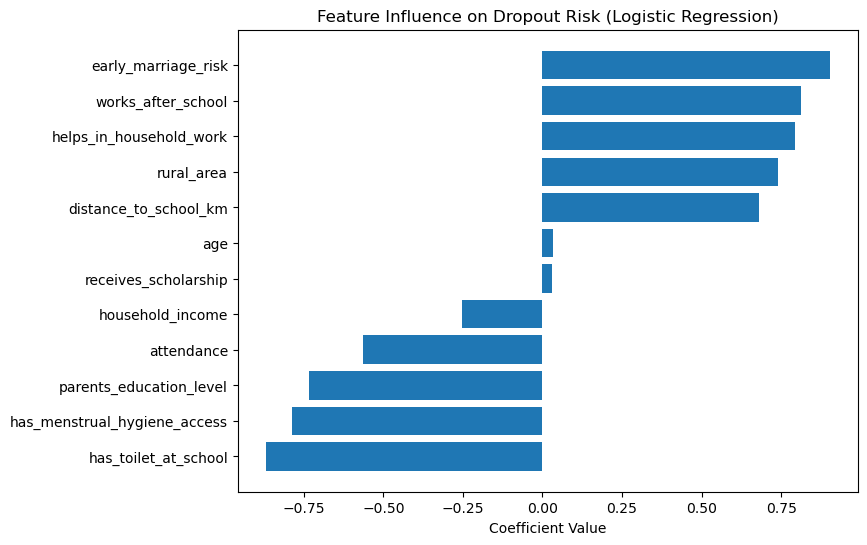

In [586]:
plt.figure(figsize = (8,6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Feature Influence on Dropout Risk (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()

### Model Performance Visualization

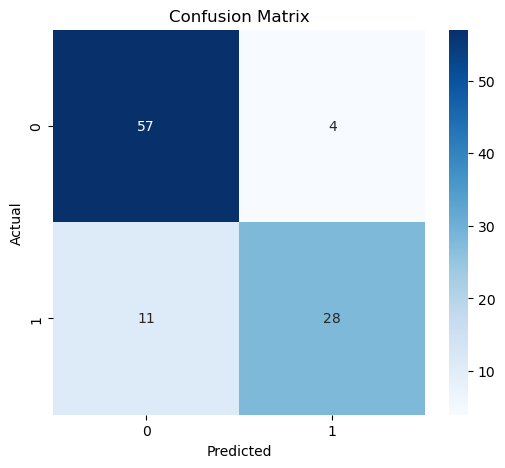

In [493]:
plt.figure(figsize = (6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best),
            annot = True,
            fmt = "d",
            cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [494]:
corr = df.corr()
corr["attendance"].sort_values()

dropout_risk                   -0.179870
distance_to_school_km          -0.114086
early_marriage_risk            -0.053004
parents_education_level        -0.052926
receives_scholarship           -0.047911
has_menstrual_hygiene_access   -0.036747
household_income               -0.035947
works_after_school             -0.008354
age                             0.028923
rural_area                      0.058825
helps_in_household_work         0.063816
has_toilet_at_school            0.072095
attendance                      1.000000
Name: attendance, dtype: float64

### SHAP Explainability

In [495]:
!pip install shap

In [496]:
import shap

C:\Users\AANCHAL\AppData\Local\Temp\ipykernel_1124\883476715.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, 1], X_test)


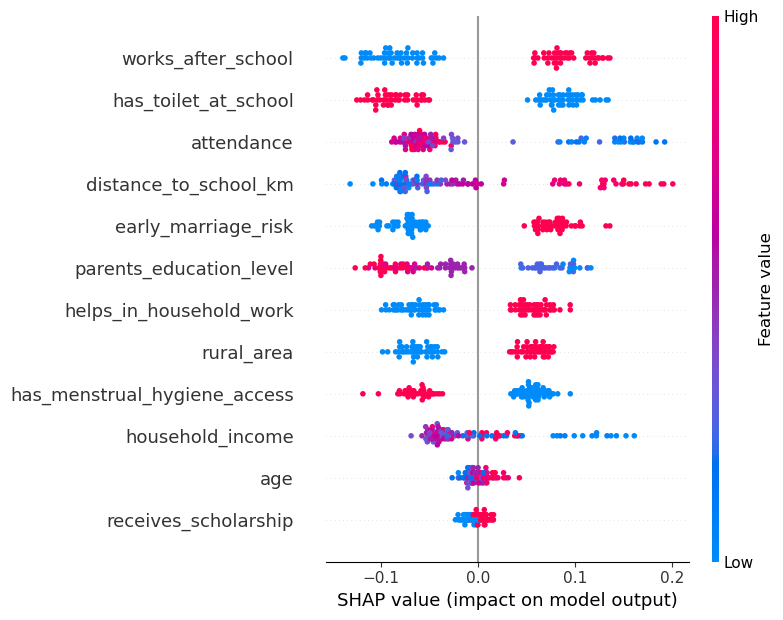

In [497]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

shap.summary_plot(shap_values.values[:, :, 1], X_test)

C:\Users\AANCHAL\AppData\Local\Temp\ipykernel_1124\203465725.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, 1], X_test, plot_type = "bar")


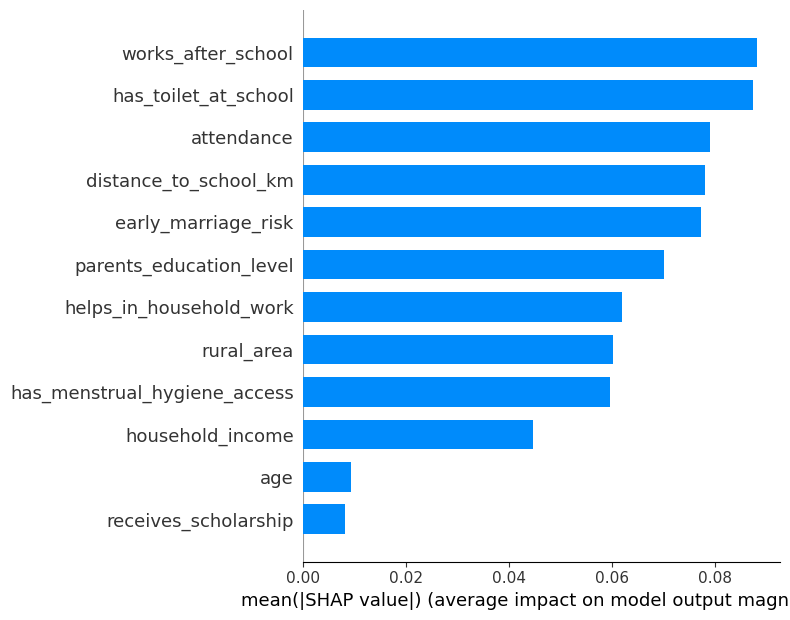

In [498]:
shap.summary_plot(shap_values.values[:, :, 1], X_test, plot_type = "bar")

In [499]:
fairness_df = X_test.copy()

fairness_df["Actual"] = y_test.values
fairness_df["Predicted"] = y_pred_best
fairness_df["Risk_Probability"] = y_prob

fairness_df.head()

,age,attendance,household_income,parents_education_level,rural_area,distance_to_school_km,has_toilet_at_school,receives_scholarship,has_menstrual_hygiene_access,helps_in_household_work,works_after_school,early_marriage_risk,Actual,Predicted,Risk_Probability
361,12,54,117545,1,1,7,0,1,0,0,1,0,1,1,0.984709
73,15,72,135703,4,1,12,1,0,1,1,0,1,0,0,0.241677
374,17,63,68070,1,0,5,1,1,0,0,1,0,1,0,0.074467
155,13,86,225459,2,1,12,1,0,1,0,0,0,0,0,0.000543
104,16,52,101427,2,0,1,0,1,0,0,0,1,0,0,0.370434


In [500]:
fairness_df.groupby("rural_area")["Risk_Probability"].mean()

rural_area
0    0.218897
1    0.514828
Name: Risk_Probability, dtype: float64

In [501]:
for group in [0,1]:
    group_data = fairness_df[fairness_df["rural_area"] == group]

    acc = accuracy_score(group_data["Actual"], group_data["Predicted"])

    print("Accuracy for rural_area = ", group, ":", acc)

Accuracy for rural_area =  0 : 0.8163265306122449
Accuracy for rural_area =  1 : 0.8823529411764706


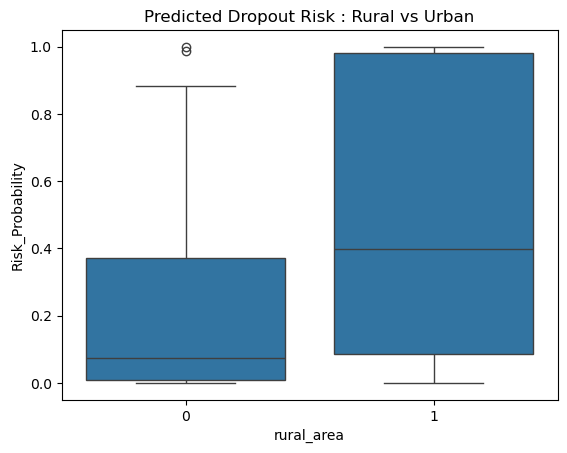

In [502]:
sns.boxplot(x = "rural_area", y = "Risk_Probability", data = fairness_df)
plt.title("Predicted Dropout Risk : Rural vs Urban")
plt.show()

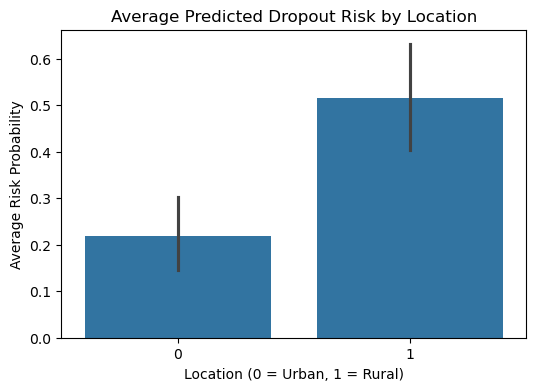

In [503]:
plt.figure(figsize = (6,4))
sns.barplot(x = "rural_area", y = "Risk_Probability", data = fairness_df)
plt.title("Average Predicted Dropout Risk by Location")
plt.xlabel("Location (0 = Urban, 1 = Rural)")
plt.ylabel("Average Risk Probability")

plt.show()

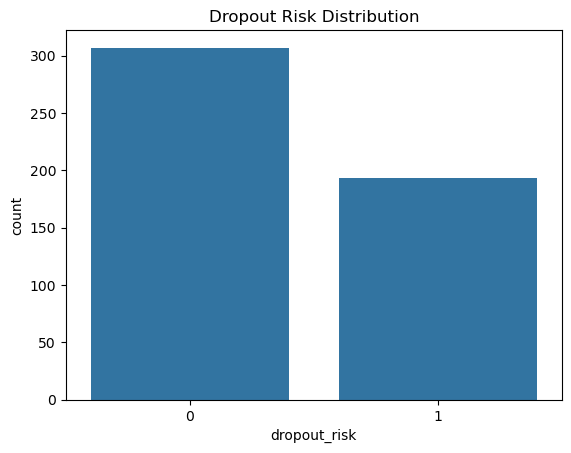

In [504]:
sns.countplot(x="dropout_risk", data=df)
plt.title("Dropout Risk Distribution")
plt.show()

### Suggested Intervention

In [505]:
def intervention(row):
    
    if row["early_marriage_risk"] == 1:
        return "Community intervention & counseling"
    
    elif row["household_income"] < 100000:
        return "Scholarship / financial support"
    
    elif row["distance_to_school_km"] > 10:
        return "Transport assistance"
    
    elif row["has_toilet_at_school"] == 0:
        return "Sanitation infrastructure improvement"
    
    elif row["works_after_school"] == 1:
        return "Child labor monitoring & support"
    
    else:
        return "Regular monitoring"

results_df["Suggested_Intervention"] = results_df.apply(intervention, axis=1)

In [506]:
dashboard = results_df.sort_values(
    by="Risk_Probability",
    ascending=False
)

dashboard.head(15)

,age,attendance,household_income,parents_education_level,rural_area,distance_to_school_km,has_toilet_at_school,receives_scholarship,has_menstrual_hygiene_access,helps_in_household_work,works_after_school,early_marriage_risk,Actual,Predicted,Risk_Probability,Risk_Category,Suggested_Intervention
455,13,53,135629,4,1,6,0,0,0,1,1,1,1,1,0.999446,High,Community intervention & counseling
72,14,86,186394,0,1,3,0,1,0,1,1,1,1,1,0.999359,High,Community intervention & counseling
450,12,60,108770,2,1,11,0,1,0,1,1,0,1,1,0.999186,High,Transport assistance
84,16,94,61605,0,1,11,0,1,0,1,1,0,1,1,0.998936,High,Scholarship / financial support
262,16,77,119201,0,0,14,0,0,1,1,1,1,1,1,0.997951,High,Community intervention & counseling
497,14,57,181300,3,1,10,0,0,0,1,0,1,1,1,0.997684,High,Community intervention & counseling
76,16,85,172581,0,1,7,1,0,0,1,1,1,1,1,0.996536,High,Community intervention & counseling
101,17,92,229182,1,1,13,0,1,0,1,1,0,1,1,0.995911,High,Transport assistance
485,16,58,94911,4,1,8,0,1,0,0,1,1,1,1,0.994277,High,Community intervention & counseling
336,13,54,194869,4,1,9,0,0,1,1,1,1,1,1,0.992558,High,Community intervention & counseling


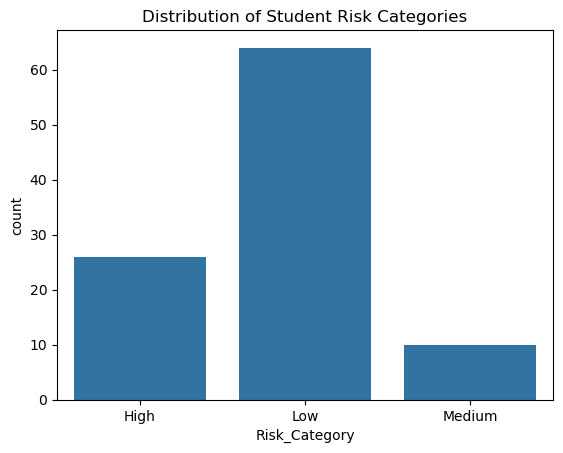

In [507]:
sns.countplot(x="Risk_Category", data=results_df)
plt.title("Distribution of Student Risk Categories")
plt.show()

# Policy Insights from the Model

## Key drivers of Dropout Risk

### Based on SHAP explainability and model analysis, the following factors were identified as major contributors to dropout risk:

1. Working after school
2.Lower parental education levels
3. Lack of sanitation facilities at school
4. Limited menstrual hygiene access
5. Rural location and distance from school

### These results highlight the socio-economic pressures affecting girls' education.

## Possible Interventions

### Based on the model's findings, the following interventions may reduce dropout risk:

### 1. Financial support Programs
Students working after school often do so due to financial pressure. Scholarships or financial assistance may help them stay in school.

### 2. Infrastructure Improvements
Improving school sanitation facilities and menstrual hygiene access can reduce dropout risk among adolescent girls.

### 3. Transport Support
Students in rural areas or living far from school may benefit from school transportation programs.

### 4. Family Awareness Programs
Household responsibilities can limit study time. Community awareness initiatives can help families prioritize girls’ education.

## How AI systems can be used to assist in the above interventions

### The system developed in this project can function as an Early Warning System for School Dropout Risk.
 #### Possible applications include:

1. Government education departments monitoring dropout risk across districts
2. NGOs identifying high-risk students for targeted interventions
3. Schools prioritizing counseling and support programs

## The model can help identify vulnerable students early, allowing preventative action.

# Limitations of this Study

1. The dataset used in this project is synthetic and does not represent real student records.
2. Cultural and regional factors may influence dropout patterns differently across India.
3. Machine learning predictions should support human decision-making rather than replace it.